# Homework 2.2

 <a name="I"></a>
### I. Import Packages and Create Model Object

In [1]:
#import packages
import flopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mp
import pandas as pd
import scipy.io

In [2]:
#create model object
modelname = "risk_analysis_model"
exe_name = 'mf2005.exe'
m = flopy.modflow.Modflow(modelname, exe_name = exe_name)

In [3]:
#Spatial Discretization
#We define a 1000 x 1000 unit model domain, and discretize this into 25 rows and columns.

<strong> Note: You will have to modify the exe_name variable to direct flopy to the modflow executable file on your computer!</strong>

 <a name="II"></a>
### II. Discretize Model and Attach DIS Package

In [4]:
#assign discretization variables
Lx = 100.
Ly = 100.
ztop = 0.
zbot = -50.
nlay = 1
nrow = 25
ncol = 25
dx = Lx/ncol
dy = Ly/nrow
dz = (ztop - zbot) / nlay

#specify number of stress periods
nper = 3
#specify if stress period is transient or steady-state
# period lengths (days)
perlen = [1., 5., 5.,]
# number of time steps per stress period
nstp = [1, 5, 10,]
# specify if stress period is transient or steady-state
steady = [False, True, True,]
#create flopy discretization object, length and time are meters (2) and days (4)
#dis = flopy.modflow.ModflowDis(model=m, nlay=nlay, nrow=nrow, ncol=ncol,
#                               #delr=dx, delc=dy, top=ztop, botm=zbot,
#                               #itmuni = 4, lenuni = 2,
#                               #nper=nper, steady=steady)
dis = flopy.modflow.ModflowDis(m, nlay=nlay, nrow=nrow, ncol=ncol,
                               delr=dx, delc=dy, top=ztop, botm=zbot,
                               itmuni=4, lenuni=2,
                               nper=nper, perlen=perlen, nstp=nstp, steady=steady)

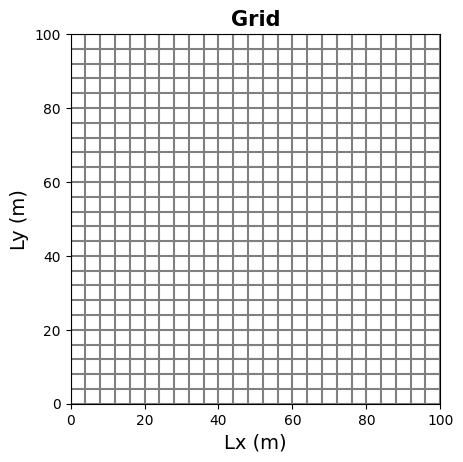

In [5]:
#CHECK GRID
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid() 
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Grid', fontsize = 15, fontweight = 'bold')
plt.show()

 <a name="III"></a>
### III. Assign Cell Activity/Starting Heads and Attach BAS Package

In [6]:
#create ibound as array of ints = 1
ibound = np.ones((nlay, nrow, ncol), dtype=np.int32)
#assign left and right boundary cells to constant head
ibound[:, :, 0] = -1
ibound[:, :, -1] = -1
# ibound[:,0,:] = -1
# ibound[:,-1,:] = -1

#create strt as array of floats = 10m
strt = np.ones((nlay, nrow, ncol), dtype=np.float32)
strt[:, :, :] = 10.
strt[:, :, 0] = 12.
# strt[:, :, 0] = 1.
# strt[:, :, -1] = 0.

#create flopy bas object
bas = flopy.modflow.ModflowBas(m, ibound=ibound, strt=strt)

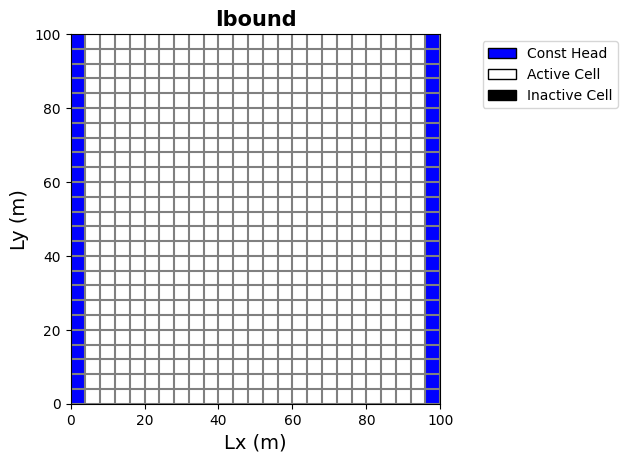

In [7]:
#CHECK IBOUND
#use flopy to plot grid and ibound
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid()
ib = modelmap.plot_ibound()
#add labels and legend
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Ibound', fontsize = 15, fontweight = 'bold')
plt.legend(handles=[mp.patches.Patch(color='blue',label='Const Head',ec='black'),
                   mp.patches.Patch(color='white',label='Active Cell',ec='black'),
                   mp.patches.Patch(color='black',label='Inactive Cell',ec='black')],
                   bbox_to_anchor=(1.5,1.0))
plt.show(modelmap)

 <a name="IV"></a>
### IV. Define Layer Properties and Attach LPF Package

In [8]:
#define horizontal and vertical hydraulic conductivity
hk = np.ones((nlay,nrow,ncol), dtype=np.float32)
vk = np.ones((nlay,nrow,ncol), dtype=np.float32)

#define specific storage
ss = np.ones((nlay,nrow,ncol), dtype=float)
ss[:,:,:] = 1e-5

#define layer type as confined
laytyp = np.zeros((nlay,), dtype=np.int32)

#create flopy layer property flow object
lpf = flopy.modflow.ModflowLpf(model=m, hk=hk, vka=vk, ss=1e-4, sy=0.1, laytyp=0)

In [9]:
#perm = loadmat('perm')['perm']
#print(hk.shape)
#hk[:,0:24,0:24]=perm[0:24,0:24]
#togliere vk

 <a name="V"></a>
# V. Create Wells and Attach MODFLOW WEL Package

For this model, we will create a single well at the center of the domain:                     

In [10]:
# Definisci le coordinate del pozzo (es. centro mappa)
p_row, p_col = 12, 12  # Usa i tuoi indici
# Crea le definizioni per i 3 momenti diversi
# Periodo 0: Pompaggio Base (-50)
well_normal = [0, p_row, p_col, -50.0]
# Periodo 1: SCENARIO DI RISCHIO (Pompaggio quintuplicato! es. siccità/industria)
well_risk = [0, p_row, p_col, -250.0]
# Periodo 2: Recupero (Ritorno a base)
well_recovery = [0, p_row, p_col, -50.0]
# Costruisci il dizionario {Periodo: [Lista Pozzi]}
risk_scenario = {
    0: [well_normal],  # Periodo 0 usa well_normal
    1: [well_risk],    # Periodo 1 usa well_risk
    2: [well_recovery] # Periodo 2 usa well_recovery
}

wel = flopy.modflow.ModflowWel(m, stress_period_data=risk_scenario)

In [11]:
#Create Dictionary With Stress Period Data
#wel_spd = {0: [well_1]} #refers to stress period 0
wel_spd = {0: [well_2,well_3], 1: [well_1,well_2], 2: [well_1,well_2,well_3]}

print("Well Stress Period Data: \n", wel_spd)

NameError: name 'well_2' is not defined

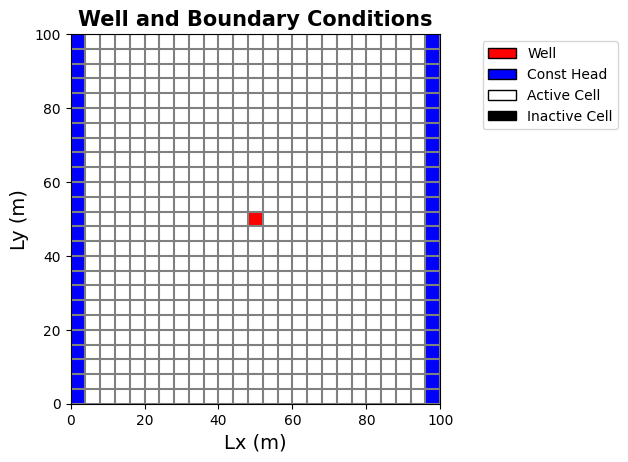

In [12]:
#CHECK WELL LOCATION
#use flopy to plot grid, ibound, and wells
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid()
ib = modelmap.plot_ibound()
wel = modelmap.plot_bc(ftype='WEL')
#add labels and legend
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Well and Boundary Conditions', fontsize = 15, fontweight = 'bold')
plt.legend(handles=[mp.patches.Patch(color='red',label='Well',ec='black'),
                   mp.patches.Patch(color='blue',label='Const Head',ec='black'),
                   mp.patches.Patch(color='white',label='Active Cell',ec='black'),
                   mp.patches.Patch(color='black',label='Inactive Cell',ec='black')],
                   bbox_to_anchor=(1.5,1.0))
plt.show(modelmap)

 <a name="VI"></a>
### VI. Specify Data Output and Attach OC Package

In [24]:
#create oc stress period data. 
#spd = {(0, 0): ['print head', 'print budget', 'save head', 'save budget']}
#oc = flopy.modflow.ModflowOc(model=m, stress_period_data=spd, compact=True)

# Dobbiamo salvare dati a ogni step per fare il grafico temporale
spd = {}
for i in range(nper):
    for j in range(nstp[i]):
        spd[(i, j)] = ['save head', 'save budget']

oc = flopy.modflow.ModflowOc(m, stress_period_data=spd)

<a name="VII"></a>
### VII. Assign PCG as Finite Difference Solver and Attach PCG Package

In [25]:
#assign groundwater flow solver
pcg = flopy.modflow.ModflowPcg(model=m)

 <a name="VIII"></a>
### VIII. Create MODFLOW files and Run Model

In [26]:
#write MODFLOW input files
m.write_input()

In [27]:
# Run the model
success, mfoutput = m.run_model(pause=False, report=True)
if not success:
    raise Exception('MODFLOW did not terminate normally.')

FloPy is using the following executable to run the model: mf2005.exe

                                  MODFLOW-2005     
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUND-WATER FLOW MODEL
                             Version 1.12.00 2/3/2017                        

 Using NAME file: risk_analysis_model.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/12/26 15:02:02

 Solving:  Stress period:     1    Time step:     1    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     2    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     3    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     4    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     5    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     6    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     7    Ground-Wa

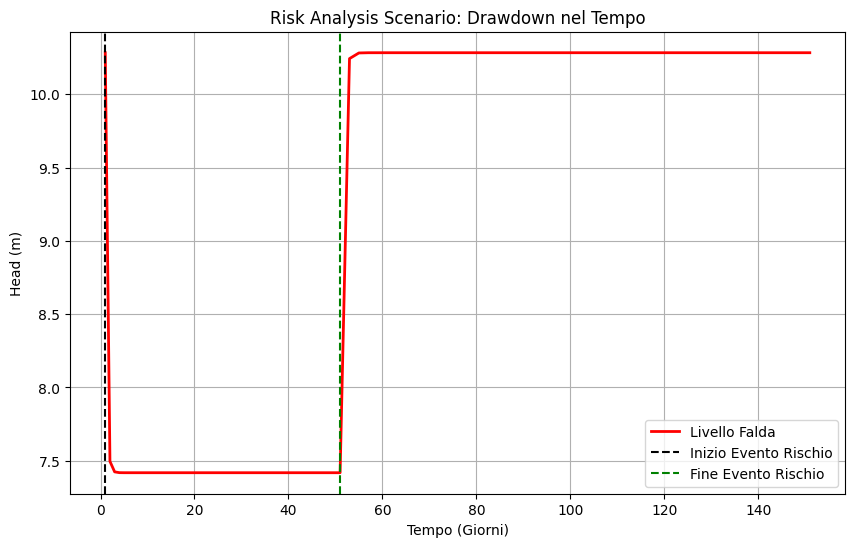

In [28]:
# --- NUOVO BLOCCO ANALISI (Post-Processing) ---

# 1. Carica i risultati
import flopy.utils.binaryfile as bf
headobj = bf.HeadFile(modelname + '.hds')

# 2. Estrai i dati nel tempo per la cella del pozzo
# (Usa le stesse coordinate p_row, p_col usate nel blocco WEL)
ts = headobj.get_ts((0, p_row, p_col))

# 3. Fai il grafico (Drawdown over time)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(ts[:, 0], ts[:, 1], 'r-', linewidth=2, label='Livello Falda')

# Abbellimento per la Risk Analysis
plt.axvline(x=1, color='k', linestyle='--', label='Inizio Evento Rischio')
plt.axvline(x=51, color='g', linestyle='--', label='Fine Evento Rischio')
plt.xlabel('Tempo (Giorni)')
plt.ylabel('Head (m)')
plt.title('Risk Analysis Scenario: Drawdown nel Tempo')
plt.legend()
plt.grid()
plt.show()

<a name="IX"></a>
### IX. Extract Head and Flow Data 

In [4]:
#extract binary data from head file
#headobj = flopy.utils.binaryfile.HeadFile(modelname+'.hds')
#head = headobj.get_data(totim=1.0)

times = [perlen[0],perlen[0]+perlen[1],perlen[0]+perlen[1]+perlen[2]] #extract times at end of each stress period
head = {} #create dictionary to store head data at end of each stress period
frf = {} #create dictionary to store flows through right cell face at end of each stress period
fff = {} #create dictionary to store flows through front cell face at end of each stress period
headobj = flopy.utils.binaryfile.HeadFile(modelname+'.hds') #get head data as python object
budgobj = flopy.utils.binaryfile.CellBudgetFile(modelname+'.cbc') #get flow data as python object
#times = headobj.get_times

NameError: name 'perlen' is not defined

In [5]:
#extract binary data from budget file
#budgobj = flopy.utils.binaryfile.CellBudgetFile(modelname+'.cbc')
#frf = budgobj.get_data(text='flow right face', totim=1.0)
#fff = budgobj.get_data(text='flow front face', totim=1.0)
print(times)
for stress_per, time in enumerate(times): #iterate trought times at end of each stress period
    print(time)
    head['sp%s'%(stress_per)] = headobj.get_data(totim=time) #append heads to head list for ea stress per
    frf['sp%s'%(stress_per)] = budgobj.get_data(text='FLOW RIGHT FACE',totim=time) #append right face flow to frf list for ea stress per
    fff['sp%s'%(stress_per)] = budgobj.get_data(text='FLOW FRONT FACE',totim=time) #append front face flow to fff list for ea stress per

NameError: name 'times' is not defined

<a name="X"></a>
## X. Plotting

### Head Contour and Flow Plot 

In [6]:
#plot results
plt.figure(figsize=(10,10)) #create 10 x 10 figure
modelmap = flopy.plot.PlotMapView(model=m, layer=0) #use modelmap to attach plot to model
grid = modelmap.plot_grid() #plot model grid
contour_levels = np.linspace(head[0].min(),head[0].max(),15) #set contour levels for contouring head
head_contours = modelmap.contour_array(head, levels=contour_levels) #create head contours
#flows = modelmap.plot_discharge(frf[0], fff[0], head=head) #create discharge arrows
flows=flopy.utils.postprocessing.get_specific_discharge(vectors=[frf[0], fff[0]], model=m, head=head)
arrows=modelmap.plot_vector(flows[0], flows[1])

#display parameters
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Steady-State Pumping, Flow(m^3/d) and Head(m) Results', fontsize = 15, fontweight = 'bold')
plt.colorbar(head_contours, aspect=5)
plt.show(modelmap)



NameError: name 'plt' is not defined

### Head Contour Plot

The aquifer head may be more easily visualized with a filled contour plot using matplotlib's contourf() function.


In [7]:
#create plot
plt.figure(figsize=(9,7))
cf = plt.contourf(np.flipud(head[0,:,:]),levels=contour_levels)
#display parameters
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Steady-State Pumping, Head(m) Results', fontsize = 15, fontweight = 'bold')
plt.colorbar(cf,aspect=10)
plt.show()

NameError: name 'plt' is not defined

### 3D Head Surface Plot

In [8]:
#import 3d axes toolkit from matplotlib
from mpl_toolkits.mplot3d import Axes3D

#create 3d figure
fig_3d = plt.figure(figsize=(12,5))
#ax = fig_3d.gca(projection='3d')
ax = fig_3d.add_subplot(projection='3d')

#set X, Y, Z variables for 3d plot to be our model domain and head solution
X = np.arange(0,Lx,dx)
Y = np.arange(0,Ly,dy)
X, Y = np.meshgrid(X, Y)
Z = np.flipud(head[0])

#create surface and labels
surf = ax.plot_surface(X,Y,Z, cmap = plt.cm.coolwarm, linewidth=0, antialiased=False, label='head')
fig_3d.colorbar(surf,shrink=0.5,aspect=5).set_label('Head (m)',fontsize=10,fontweight='bold')
ax.set_xlabel('Lx (m)', fontsize=15, fontweight='bold')
ax.set_ylabel('Ly (m)', fontsize=15, fontweight='bold')
ax.set_title('Steady-State Pumping, Head Surface', fontsize=15, fontweight='bold')
plt.show(surf)

NameError: name 'plt' is not defined

### Head Transect Plot

It may also be helpful to visualize the head profile along a single row. Below the head head data is extracted halfway up Ly and plotted across Lx.

In [ ]:
#plot head head transect
plt.figure(figsize = (10,4))
x = np.arange(0,Lx,dx)
plt.plot(x,np.flipud(head[0])[int(nrow-rowwell_1)][:])
plt.title('Head Transect across X-Domain',fontweight = 'bold', fontsize = 14)
plt.xlabel('X Distance (m)',fontsize = 12)
plt.ylabel('Head (m)',fontsize = 12)
plt.show()

<strong> Activities: </strong> 
- Increase pumping rates and observe the changes in head surface/drawdown extent.
- Add another pumping well variable, well_2, to the well package and rerun the model with two wells.
- Change the location of well_1 and observe different interactions with the constant head boundary conditions.
- Change the IBOUND to accomodate active flux boundaries on the top and bottom of the model edges and observe differences in head surface symmetry.